In [1]:
import cobra
import escher
import pandas as pd
import numpy as np
import json
import csv
from cobra.io import save_json_model
from cobra import Reaction
from cobra.flux_analysis.loopless import add_loopless, loopless_solution
import matplotlib.pyplot as plt

In [2]:
cobra.Configuration().solver = "cplex"

In [3]:
import sys
print(sys.version)

3.7.16 (default, Jan 17 2023, 16:06:28) [MSC v.1916 64 bit (AMD64)]


In [4]:
print(cobra.__version__)

0.28.0


In [5]:
model_path = 'iMT1026v3.xml'
#model_path = 'iPichia.xml'

model = cobra.io.read_sbml_model(model_path)

model

Model does not contain SBML fbc package information.
SBML package 'layout' not supported by cobrapy, information is not parsed
SBML package 'render' not supported by cobrapy, information is not parsed
Use of FORMULA in the notes element is discouraged, use fbc:chemicalFormula instead: <Species M_oligoP_v "oligophosphate (5-P)">
Use of FORMULA in the notes element is discouraged, use fbc:chemicalFormula instead: <Species M_polyP_v "polyphosphate (100-P)">
Use of FORMULA in the notes element is discouraged, use fbc:chemicalFormula instead: <Species M_h2o_v "H2O">
Use of FORMULA in the notes element is discouraged, use fbc:chemicalFormula instead: <Species M_h2o_c "H2O">
Use of FORMULA in the notes element is discouraged, use fbc:chemicalFormula instead: <Species M_ppi_c "Diphosphate">
Use of FORMULA in the notes element is discouraged, use fbc:chemicalFormula instead: <Species M_h_c "H+">
Use of FORMULA in the notes element is discouraged, use fbc:chemicalFormula instead: <Species M_pi_c

Use of FORMULA in the notes element is discouraged, use fbc:chemicalFormula instead: <Species M_nmn_c "Nicotinamide D-ribonucleotide">
Use of FORMULA in the notes element is discouraged, use fbc:chemicalFormula instead: <Species M_amp_m "AMP">
Use of FORMULA in the notes element is discouraged, use fbc:chemicalFormula instead: <Species M_nmn_m "Nicotinamide D-ribonucleotide">
Use of FORMULA in the notes element is discouraged, use fbc:chemicalFormula instead: <Species M_nadp_c "NADP">
Use of FORMULA in the notes element is discouraged, use fbc:chemicalFormula instead: <Species M_nadp_m "NADP">
Use of FORMULA in the notes element is discouraged, use fbc:chemicalFormula instead: <Species M_nadh_m "NADH">
Use of FORMULA in the notes element is discouraged, use fbc:chemicalFormula instead: <Species M_nadph_m "NADPH">
Use of FORMULA in the notes element is discouraged, use fbc:chemicalFormula instead: <Species M_nadph_c "NADPH">
Use of FORMULA in the notes element is discouraged, use fbc:ch

Use of FORMULA in the notes element is discouraged, use fbc:chemicalFormula instead: <Species M_gln_L_m "L-Glutamine">
Use of FORMULA in the notes element is discouraged, use fbc:chemicalFormula instead: <Species M_nh4_n "Ammonium">
Use of FORMULA in the notes element is discouraged, use fbc:chemicalFormula instead: <Species M_dnad_n "Deamino-NAD+">
Use of FORMULA in the notes element is discouraged, use fbc:chemicalFormula instead: <Species M_h_n "H+">
Use of FORMULA in the notes element is discouraged, use fbc:chemicalFormula instead: <Species M_ppi_n "Diphosphate">
Use of FORMULA in the notes element is discouraged, use fbc:chemicalFormula instead: <Species M_amp_n "AMP">
Use of FORMULA in the notes element is discouraged, use fbc:chemicalFormula instead: <Species M_nad_n "NAD+">
Use of FORMULA in the notes element is discouraged, use fbc:chemicalFormula instead: <Species M_ala_L_c "L-Alanine">
Use of FORMULA in the notes element is discouraged, use fbc:chemicalFormula instead: <Spe

Use of FORMULA in the notes element is discouraged, use fbc:chemicalFormula instead: <Species M_eicoscoa_x "Eicosanoyl-CoA">
Use of FORMULA in the notes element is discouraged, use fbc:chemicalFormula instead: <Species M_eicos2coa_x "trans-Eicosa-2-enoyl-CoA">
Use of FORMULA in the notes element is discouraged, use fbc:chemicalFormula instead: <Species M_dcoscoa_x "Docosanoyl-CoA">
Use of FORMULA in the notes element is discouraged, use fbc:chemicalFormula instead: <Species M_dcos2coa_x "trans-Docosa-2-enoyl-CoA">
Use of FORMULA in the notes element is discouraged, use fbc:chemicalFormula instead: <Species M_ttccoa_x "Tetracosanoyl-CoA">
Use of FORMULA in the notes element is discouraged, use fbc:chemicalFormula instead: <Species M_ttc2coa_x "trans-Tetracosa-2-enoyl-CoA">
Use of FORMULA in the notes element is discouraged, use fbc:chemicalFormula instead: <Species M_hexccoa_x "Hexacosanoyl-CoA">
Use of FORMULA in the notes element is discouraged, use fbc:chemicalFormula instead: <Speci

Use of FORMULA in the notes element is discouraged, use fbc:chemicalFormula instead: <Species M_pi_n "Phosphate">
Use of FORMULA in the notes element is discouraged, use fbc:chemicalFormula instead: <Species M_glu_L_n "L-Glutamate">
Use of FORMULA in the notes element is discouraged, use fbc:chemicalFormula instead: <Species M_cbp_n "Carbamoyl phosphate">
Use of FORMULA in the notes element is discouraged, use fbc:chemicalFormula instead: <Species M_pser_L_c "O-Phospho-L-serine">
Use of FORMULA in the notes element is discouraged, use fbc:chemicalFormula instead: <Species M_acser_c "O-Acetyl-L-serine">
Use of FORMULA in the notes element is discouraged, use fbc:chemicalFormula instead: <Species M_trnaala_m "tRNA(Ala)">
Use of FORMULA in the notes element is discouraged, use fbc:chemicalFormula instead: <Species M_amet_m "S-Adenosyl-L-methionine">
Use of FORMULA in the notes element is discouraged, use fbc:chemicalFormula instead: <Species M_ahcys_m "S-Adenosyl-L-homocysteine">
Use of F

...

Encoding OBJECTIVE_COEFFICIENT in KineticLaw is discouraged, use fbc:fluxObjective instead: <Reaction R_Ex_iamoh "Isoamyl alcohol exchange">
Encoding OBJECTIVE_COEFFICIENT in KineticLaw is discouraged, use fbc:fluxObjective instead: <Reaction R_Ex_ibutac "isobutyl acetate exchange">
Encoding OBJECTIVE_COEFFICIENT in KineticLaw is discouraged, use fbc:fluxObjective instead: <Reaction R_Ex_ibutoh "Isobutyl alcohol exchange">
Encoding OBJECTIVE_COEFFICIENT in KineticLaw is discouraged, use fbc:fluxObjective instead: <Reaction R_Ex_id3acald "Indole-3-acetaldehyde exchange">
Encoding OBJECTIVE_COEFFICIENT in KineticLaw is discouraged, use fbc:fluxObjective instead: <Reaction R_Ex_ile_L "L-Isoleucine exchange">
Encoding OBJECTIVE_COEFFICIENT in KineticLaw is discouraged, use fbc:fluxObjective instead: <Reaction R_Ex_ind3eth "Indole-3-ethanol exchange">
Encoding OBJECTIVE_COEFFICIENT in KineticLaw is discouraged, use fbc:fluxObjective instead: <Reaction R_Ex_ins "Inosine exchange">
Encoding O

Encoding OBJECTIVE_COEFFICIENT in KineticLaw is discouraged, use fbc:fluxObjective instead: <Reaction R_D_ABTt "D-arabinitol transport via passive diffusion">
Encoding OBJECTIVE_COEFFICIENT in KineticLaw is discouraged, use fbc:fluxObjective instead: <Reaction R_Ex_abt_D "D-Arabitol exchange">
Encoding OBJECTIVE_COEFFICIENT in KineticLaw is discouraged, use fbc:fluxObjective instead: <Reaction R_RU5PP "Ribulose 5-phosphatase">
Encoding OBJECTIVE_COEFFICIENT in KineticLaw is discouraged, use fbc:fluxObjective instead: <Reaction R_DABTDHR "D-arabitol dehydrogenase (D-ribulose-forming)">
Encoding OBJECTIVE_COEFFICIENT in KineticLaw is discouraged, use fbc:fluxObjective instead: <Reaction R_RBK_D "D-ribulokinase">
Encoding OBJECTIVE_COEFFICIENT in KineticLaw is discouraged, use fbc:fluxObjective instead: <Reaction R_DABTDEH "D-arabitol dehydrogenase (D-ribulose-forming)">
Encoding OBJECTIVE_COEFFICIENT in KineticLaw is discouraged, use fbc:fluxObjective instead: <Reaction R_Htr "H+ transpo

Encoding OBJECTIVE_COEFFICIENT in KineticLaw is discouraged, use fbc:fluxObjective instead: <Reaction R_FAE2_14 "3-tetradecanoyl-CoA reductase">
Encoding OBJECTIVE_COEFFICIENT in KineticLaw is discouraged, use fbc:fluxObjective instead: <Reaction R_FAE2_16 "3-hexadecanoyl-CoA reductase">
Encoding OBJECTIVE_COEFFICIENT in KineticLaw is discouraged, use fbc:fluxObjective instead: <Reaction R_FAE2_18 "3-octadecanoyl-CoA reductase">
Encoding OBJECTIVE_COEFFICIENT in KineticLaw is discouraged, use fbc:fluxObjective instead: <Reaction R_FAE2_20 "3-Eicosanoyl-CoA reductase">
Encoding OBJECTIVE_COEFFICIENT in KineticLaw is discouraged, use fbc:fluxObjective instead: <Reaction R_FAE2_22 "3-Docosanoyl-CoA reductase">
Encoding OBJECTIVE_COEFFICIENT in KineticLaw is discouraged, use fbc:fluxObjective instead: <Reaction R_FAE2_24 "3-tetracosanoyl-CoA reductase">
Encoding OBJECTIVE_COEFFICIENT in KineticLaw is discouraged, use fbc:fluxObjective instead: <Reaction R_FAE2_26 "3-hexacosanoyl-CoA reduct

Encoding OBJECTIVE_COEFFICIENT in KineticLaw is discouraged, use fbc:fluxObjective instead: <Reaction R_RPEx "ribulose 5-phosphate 3-epimerase">
Encoding OBJECTIVE_COEFFICIENT in KineticLaw is discouraged, use fbc:fluxObjective instead: <Reaction R_DHAPtx "Dihydroxyacetone phosphate transport from peroxisomes">
Encoding OBJECTIVE_COEFFICIENT in KineticLaw is discouraged, use fbc:fluxObjective instead: <Reaction R_FA140tpc "Tetradecanoate transport out of peroxisome">
Encoding OBJECTIVE_COEFFICIENT in KineticLaw is discouraged, use fbc:fluxObjective instead: <Reaction R_FA141tpc "Tetradecenoate transport out of peroxisome">
Encoding OBJECTIVE_COEFFICIENT in KineticLaw is discouraged, use fbc:fluxObjective instead: <Reaction R_FA160tpc "Hexadecanoate transport out of peroxisome">
Encoding OBJECTIVE_COEFFICIENT in KineticLaw is discouraged, use fbc:fluxObjective instead: <Reaction R_FA161tpc "Hexadecenoate transport out of peroxisome">
Encoding OBJECTIVE_COEFFICIENT in KineticLaw is disco

Name,iMT1026v3
Memory address,180f39f3688
Number of metabolites,1706
Number of reactions,2237
Number of genes,1026
Number of groups,77
Objective expression,1.0*Ex_biomass - 1.0*Ex_biomass_reverse_5354f
Compartments,"Vacuole, Cytosol, Mitochondria, Peroxisome, Extracellular space, Endoplasmic Reticulum, Golgi Apparatus, Nucleus, Mitochondrial intermembrane space"


In [6]:
model.summary()

Metabolite,Reaction,Flux,C-Number,C-Flux
glyc_e,Ex_glyc,1,3,100.00%
nh4_e,Ex_nh4,0.3582,0,0.00%
o2_e,Ex_o2,1.45,0,0.00%
pi_e,Ex_pi,0.01453,0,0.00%
so4_e,Ex_so4,0.002533,0,0.00%
Metabolite,Reaction,Flux,C-Number,C-Flux
biomass_e,Ex_biomass,-0.05775,0,0.00%
co2_e,Ex_co2,-0.9782,1,100.00%
h_e,Ex_h,-0.3754,0,0.00%
h2o_e,Ex_h2o,-2.715,0,0.00%


In [7]:
# Change grwoth on glycerol to growth on 60% glucose and 40% methanol
# Add reaction describing this growth

biomass_gly = model.reactions.get_by_id('BIOMASS_glyc')
biomass_gly.bounds = (0,0)
biomass_gly

carbs = model.metabolites.get_by_id('CARBOHYDRATES_c')
DNA = model.metabolites.get_by_id('DNA_c')
lipids = model.metabolites.get_by_id('LIPIDS_c')
prot = model.metabolites.get_by_id('PROTEIN_c')
RNA = model.metabolites.get_by_id('RNA_c')
atp = model.metabolites.get_by_id('atp_c')
cof = model.metabolites.get_by_id('cof_c')
h2o = model.metabolites.get_by_id('h2o_c')
adp = model.metabolites.get_by_id('adp_c')
biomass = model.metabolites.get_by_id('biomass_c')
h = model.metabolites.get_by_id('h_c')
pi = model.metabolites.get_by_id('pi_c')

biomass_glc_meoh = Reaction ('biomass_glc_meoh_60/40')
biomass_glc_meoh.name = 'Biomass composition (g/g) - 60/40 Glucose/Methanol'
biomass_glc_meoh.add_metabolites({carbs: -0.33,
                                   DNA: -0.001,
                                   lipids: -0.042,
                                   prot: -0.49,
                                   RNA: -0.058,
                                   atp: -63.85,
                                   cof: -1,
                                   h2o: -63.85,
                                   adp: 63.85,
                                   pi: 63.85,
                                   biomass: 1,
                                   h: 63.85})
biomass_glc_meoh

Reaction identifier,biomass_glc_meoh_60/40
Name,Biomass composition (g/g) - 60/40 Glucose/Methanol
Memory address,0x180c059a588
Stoichiometry,0.33 CARBOHYDRATES_c + 0.001 DNA_c + 0.042 LIPIDS_c + 0.49 PROTEIN_c + 0.058 RNA_c + 63.85 atp_c + cof_c + 63.85 h2o_c --> 63.85 adp_c + biomass_c + 63.85 h_c + 63.85 pi_c 0.33 Carbohydrates + 0.001 DNA + 0.042 Lipids + 0.49 PROTEIN + 0.058 RNA + 63.85 ATP + Cofactors and small molecules + 63.85 H2O --> 63.85 ADP + Biomass + 63.85 H+ + 63.85 Phosphate
GPR,
Lower bound,0.0
Upper bound,1000.0


In [8]:
# Add new biomass reaction to the model

print (len(model.reactions))
model.add_reactions([biomass_glc_meoh])
print (len(model.reactions))

2237
2238


In [9]:
BIOMASS_GLCMEOH = model.reactions.get_by_id('biomass_glc_meoh_60/40')

In [10]:
#Tanquem l'entrada de Glicerol
glycerol_exchange = model.exchanges.get_by_id('Ex_glyc')
glycerol_exchange.bounds = (0,0)
glycerol_exchange

Reaction identifier,Ex_glyc
Name,Glycerol exchange
Memory address,0x180bec2c1c8
Stoichiometry,glyc_e --> Glycerol -->
GPR,
Lower bound,0
Upper bound,0


In [11]:
# Add qmeoh constraints observed in chemostat cultivations
methanol_exchange = model.exchanges.get_by_id('Ex_meoh')
methanol_exchange.bounds = (-1.24, -1.18)
methanol_exchange

Reaction identifier,Ex_meoh
Name,Methanol exchange
Memory address,0x180bec2ce08
Stoichiometry,meoh_e <-- Methanol <--
GPR,
Lower bound,-1.24
Upper bound,-1.18


In [12]:
# Add qgluc constraints observed in chemostat cultivations
glucose_exchange = model.reactions.get_by_id('Ex_glc_D')
glucose_exchange.bounds = (-0.72, -0.7)
glucose_exchange

Reaction identifier,Ex_glc_D
Name,D-Glucose exchange
Memory address,0x180beb38f48
Stoichiometry,glc_D_e <-- D-Glucose <--
GPR,
Lower bound,-0.72
Upper bound,-0.7


In [13]:
# Change the reactions for the synthesis of lipids, proteins and sterols from glycerol to those from glucose

model.reactions.get_by_id('LIPIDS_glyc').bounds = (0,0)
model.reactions.get_by_id('PROTEINS_glyc').bounds = (0,0)
model.reactions.get_by_id('STEROLS_glyc').bounds = (0,0)

# note: these reactions from glucose do not have the glucose specification
model.reactions.get_by_id('LIPIDS').bounds = (0,1000)
model.reactions.get_by_id('PROTEINS').bounds = (0,1000)
model.reactions.get_by_id('STEROLS').bounds = (0,1000)

In [14]:
# ATP maintenance requirement (NGAME = Non-Growth Associated Maintenance Energy) based on previous studies on 
# the growth of X33-ROL on Gluc/MeOH from the group (Eric's Master Thesis)

model.reactions.get_by_id('ATPM').bounds = (1.96, 1000)

In [15]:
rolAA = model.reactions.get_by_id('rolAA')
rolAA.bounds = (0,1000)
rolRNA = model.reactions.get_by_id('rolRNA')
rolRNA.bounds = (0,1000)
rolDNA = model.reactions.get_by_id('rolDNA')
rolDNA.bounds = (0,1000)
pROL = model.reactions.get_by_id('pROL')
pROL.bounds = (0,1000)
Rol_transport =  model.reactions.get_by_id('ROLt')
Rol_transport.bounds = (0,1000)
ROL_exchange = model.exchanges.get_by_id('Ex_rol')
#ROL_exchange.bounds = (0.0003773,1000)
ROL_exchange.bounds = (0.003,1000) # Inferit de Bradford

pFAB = model.reactions.get_by_id('pFAB')
pFAB.bounds = (0,0)
fabAA = model.reactions.get_by_id('fabAA')
fabAA.bounds = (0,0)
fabt = model.reactions.get_by_id('fabt')
fabt.bounds = (0,0)
fabRNA = model.reactions.get_by_id('fabRNA')
fabRNA.bounds = (0,0)
fabDNA = model.reactions.get_by_id('fabDNA')
FAB_exchange = model.exchanges.get_by_id('Ex_fab')
FAB_exchange.bounds = (0,0)


# Extra reactions that must be closed for simulations to run smoothly:

APAT2r = model.reactions.get_by_id('APAT2r')
APAT2r.bounds = (0,0) # reaction not present in Pichia, it is yet to be removed from the model

MMSAD3 = model.reactions.get_by_id('MMSAD3')
MMSAD3.bounds = (0,0) # The reduction reaction of MSA into Acetil-CoA it is due to an unspecific effect. Reaction
# under evaluation of being kept or not.

In [16]:
#Creating the cPOS5 reaction
atp_c = model.metabolites.get_by_id('atp_c')
nadh_c = model.metabolites.get_by_id('nadh_c')
adp_c = model.metabolites.get_by_id('adp_c')
nadph_c = model.metabolites.get_by_id('nadph_c')
h_c = model.metabolites.get_by_id('h_c')

cPOS5 = Reaction('cPOS5')
cPOS5.name = 'Cytosolic NADH Kinase from Saccharomyces cerevisiae'
cPOS5.add_metabolites({atp_c: -1, 
                           nadh_c: -1, 
                           adp_c: 1, 
                           nadph_c: 1,
                               h_c: 1})
cPOS5.bounds = (0,0)
print (cPOS5.reaction)
cPOS5

# from Saccharomyces. Found in Brenda ('for references in articles please use BRENDA:EC2.7.1.86')
# Also in Uniprot with ID Q06892 and ID YPL188W (Saccharomyces Genome Database)
# It is a kinase from the mitochondrial matrix (Outten and Culotta, 2003)
# Although it is a mitochondrial enzyme in Saccharomyces, Marius et al. (2) added a tag to express it in the cytosol
# you sure about the above? It says in page of his thesis that it was truncated: they removed the first 49 bp of the
# gene in order to remove the peptide leading sequence, ensuring that it would stay in the cytosol and not go to the
# mitochondria

atp_c + nadh_c --> adp_c + h_c + nadph_c


Reaction identifier,cPOS5
Name,Cytosolic NADH Kinase from Saccharomyces cerevisiae
Memory address,0x180c05b6608
Stoichiometry,atp_c + nadh_c --> adp_c + h_c + nadph_c ATP + NADH --> ADP + H+ + NADPH
GPR,
Lower bound,0
Upper bound,0


In [17]:
print (len(model.reactions))
model.add_reactions([cPOS5])
print (len(model.reactions))

2238
2239


In [18]:
nad_c = model.metabolites.get_by_id('nad_c')
nadp_c = model.metabolites.get_by_id('nadp_c')

In [19]:
nadph_m = model.metabolites.get_by_id('nadph_m')
nadh_m = model.metabolites.get_by_id('nadh_m')
nad_m = model.metabolites.get_by_id('nad_m')
nadp_m = model.metabolites.get_by_id('nadp_m')

In [20]:
ArabitolSecretion = model.exchanges.get_by_id('Ex_abt_D')
ICL_Reaction = model.reactions.get_by_id('ICLx')
FBA_Reaction = model.reactions.get_by_id('FBA')
MAE2m_Reaction = model.reactions.get_by_id('ME2m')
MAE1m_Reaction = model.reactions.get_by_id('ME1m')
MAE1_Reaction = model.reactions.get_by_id('ME1')
MALSp_Reaction = model.reactions.get_by_id('MALSp')
CSm_Reaction = model.reactions.get_by_id('CSm')
ALCD19_Reaction = model.reactions.get_by_id('ALCD19')
MDHm_Reaction = model.reactions.get_by_id('MDHm')
PDH_Reaction = model.reactions.get_by_id('PDHcm')
NADHD_Reaction = model.reactions.get_by_id('NADH2_u6m')

In [21]:
# REACTION RATIOS PER GLUCOSA METANOL

ReactionRatio1 = model.problem.Constraint(model.reactions.CSm.flux_expression - model.reactions.ACONTm.flux_expression,
                                         lb=0,
                                         ub=0)
model.add_cons_vars(ReactionRatio1)

ReactionRatio2 = model.problem.Constraint(model.reactions.AKGDam.flux_expression - model.reactions.FUMm.flux_expression,
                                         lb=0,
                                         ub=0)
model.add_cons_vars(ReactionRatio2)

ReactionRatio8 = model.problem.Constraint(68*model.reactions.AKGDam.flux_expression - 46*model.reactions.CSm.flux_expression,
                                         lb=0,
                                         ub=0)
model.add_cons_vars(ReactionRatio8)

ReactionRatio9 = model.problem.Constraint(model.reactions.G6PDH2.flux_expression - model.reactions.GND.flux_expression,
                                         lb=0,
                                         ub=0)
model.add_cons_vars(ReactionRatio9)

ReactionRatio10 = model.problem.Constraint(0.8*model.reactions.MDHm.flux_expression - model.reactions.FUMm.flux_expression,
                                         lb=0,
                                         ub=0)
model.add_cons_vars(ReactionRatio10)

ReactionRatio12 = model.problem.Constraint(35*model.reactions.PYK.flux_expression - 143*model.reactions.PC.flux_expression,
                                         lb=0,
                                         ub=0)
model.add_cons_vars(ReactionRatio12)

ReactionRatio13 = model.problem.Constraint(68*model.reactions.PYK.flux_expression - 143*model.reactions.PYRt2m.flux_expression,
                                         lb=0,
                                         ub=0)
model.add_cons_vars(ReactionRatio13)


ReactionRatio14 = model.problem.Constraint(40*model.reactions.GAPD.flux_expression - 145*model.reactions.FBA.flux_expression,
                                         lb=0,
                                         ub=0)
model.add_cons_vars(ReactionRatio14)


ReactionRatio16 = model.problem.Constraint(model.reactions.GAPD.flux_expression - model.reactions.PYK.flux_expression,
                                         lb=0,
                                         ub=0)
model.add_cons_vars(ReactionRatio16)

ReactionRatio20 = model.problem.Constraint(0.18*model.reactions.FALDtx.flux_expression - 0.82*model.reactions.DAS.flux_expression,
                                         lb=0,
                                         ub=0)
model.add_cons_vars(ReactionRatio20)

ReactionRatio21 = model.problem.Constraint(model.reactions.G6PDH2.flux_expression + 0.4*model.reactions.Ex_glc_D.flux_expression,
                                         lb=0,
                                         ub=0)
model.add_cons_vars(ReactionRatio21)

### pFBA Simulation for Reference WT

In [22]:
pfba_WT = cobra.flux_analysis.pfba(model)

In [23]:
pfba_WT.fluxes['Ex_rol']

0.003

In [24]:
pfba_WT.fluxes['Ex_biomass']

0.08043226373244569

In [25]:
pfba_WT.fluxes['Ex_co2']

2.362878923397944

In [26]:
pfba_WT.fluxes['Ex_o2']

-2.893938162906779

In [27]:
pfba_WT.fluxes['Ex_glc_D']

-0.72

In [28]:
TPIRefFlux = pfba_WT.fluxes['TPI']
TPIRefFlux

0.5000296945426449

## MOMA Simulations

### Carbon Source: Glc/MeOH

In [29]:
# Remove Reaction Ratio Constraints before starting MOMA simulations

ReactionRatioList = [ReactionRatio1, ReactionRatio2, ReactionRatio8, ReactionRatio9, ReactionRatio10,
                     ReactionRatio12, ReactionRatio13, ReactionRatio14, ReactionRatio16, ReactionRatio20, ReactionRatio21]
                    

model.remove_cons_vars(ReactionRatioList)

In [30]:
TPIrange = (1, 0.95, 0.9, 0.85, 0.8, 0.75, 0.7, 0.65, 0.6, 0.55, 0.5, 0.45, 0.4, 0.35, 0.3, 0.25, 0.2, 0.15, 0.1, 0.05, 0)
TPI = model.reactions.get_by_id('TPI')

In [31]:
#MOMA non-linear Simulations Glucose 60 MeOH 40 Overexpressing POS5 and KD TPI
MomaResults = []
for x in TPIrange:
        b = TPIRefFlux*x
        TPI.bounds = (b, b)
        
        # Perform MOMA
        moma_result = cobra.flux_analysis.moma(model,pfba_WT,0) #Boolean per si el MOMA es lineal o no
        MomaResults.append(moma_result.fluxes)
                 
        print(TPI.bounds, moma_result.fluxes['Ex_rol'], moma_result.fluxes['Ex_biomass'],  moma_result.fluxes['Ex_o2'],  moma_result.fluxes['Ex_co2'])
        

(0.5000296945426449, 0.5000296945426449) 0.003 0.08043226373244569 -2.893938162906562 2.3628789233987413
(0.47502820981551264, 0.47502820981551264) 0.0032987032655686062 0.0796117897056196 -2.8970520144538687 2.3648696788696277
(0.45002672508838043, 0.45002672508838043) 0.0035997770308087503 0.07878602416011155 -2.900174136389228 2.3668602614057006
(0.42502524036124817, 0.42502524036124817) 0.003903363685465247 0.07795525870964166 -2.9032979063434703 2.3688471699452682
(0.40002375563411596, 0.40002375563411596) 0.004207281784374028 0.07712399524434504 -2.9064176434874667 2.3708290528465703
(0.3750222709069837, 0.3750222709069837) 0.004511301448205378 0.07629231921775362 -2.909538023198739 2.3728077545228743
(0.3500207861798514, 0.3500207861798514) 0.004815452567970524 0.07546035818425652 -2.9126583229242513 2.374786925505037
(0.3250193014527192, 0.3250193014527192) 0.005119685130030431 0.07462822056029088 -2.9157785729292747 2.3767663875791
(0.3000178167255869, 0.3000178167255869) 0.00

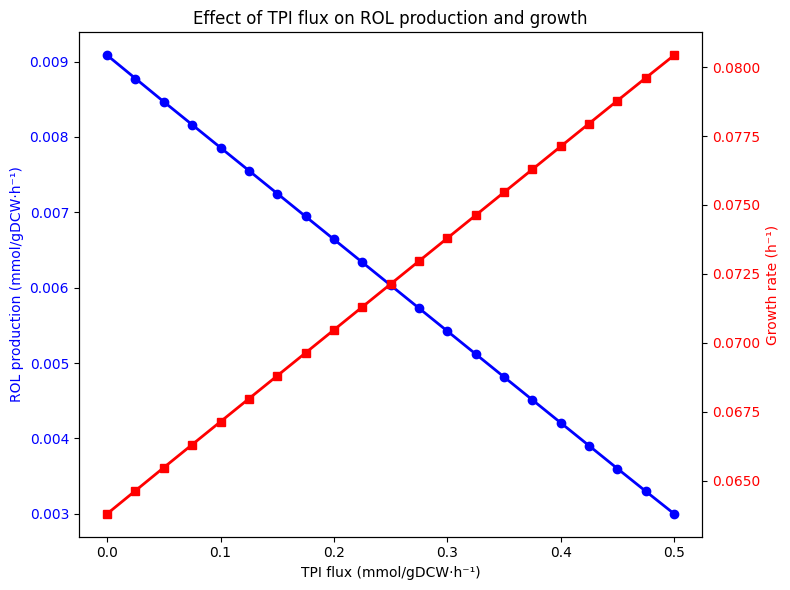

In [32]:
# Extract data from MOMA results
TPI_fluxes = []
ROL_production = []
Biomass = []

for fluxes in MomaResults:
    TPI_fluxes.append(fluxes["TPI"])
    ROL_production.append(fluxes["Ex_rol"])
    Biomass.append(fluxes["Ex_biomass"])


# Create figure
fig, ax1 = plt.subplots(figsize=(8, 6))

# --- ROL production ---
ax1.plot(
    TPI_fluxes,
    ROL_production,
    marker='o',
    linewidth=2,
    color='blue'
)

ax1.set_xlabel("TPI flux (mmol/gDCW·h⁻¹)")
ax1.set_ylabel("ROL production (mmol/gDCW·h⁻¹)", color='blue')
ax1.tick_params(axis='y', labelcolor='blue')


# --- Biomass ---
ax2 = ax1.twinx()

ax2.plot(
    TPI_fluxes,
    Biomass,
    marker='s',
    linewidth=2,
    color='red'
)

ax2.set_ylabel("Growth rate (h⁻¹)", color='red')
ax2.tick_params(axis='y', labelcolor='red')


plt.title("Effect of TPI flux on ROL production and growth")

plt.tight_layout()

# Save as PDF
plt.savefig(
    "TPI_MOMA_ROL_Growth.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()
plt.close()

In [35]:
#MOMA non-linear Simulations Glucose 60 MeOH 40 Overexpressing POS5 and KD TPI
cPOS5.bounds = (0.11, 0.11)
MomaResults = []
for x in TPIrange:
        b = TPIRefFlux*x
        TPI.bounds = (b, b)
        
        # Perform MOMA
        moma_result = cobra.flux_analysis.moma(model,pfba_WT,0) #Boolean per si el MOMA es lineal o no
        MomaResults.append(moma_result.fluxes)
                 
        print(TPI.bounds, moma_result.fluxes['Ex_rol'], moma_result.fluxes['Ex_biomass'],  moma_result.fluxes['Ex_o2'],  moma_result.fluxes['Ex_co2'])
        

(0.5000296945426449, 0.5000296945426449) 0.004309815230387847 0.07774044342980393 -2.896366681238298 2.3642654850445655
(0.47502820981551264, 0.47502820981551264) 0.004581905826320591 0.0770394445780967 -2.89788246682962 2.3647950424334883
(0.45002672508838043, 0.45002672508838043) 0.004864113498388227 0.07627164673984302 -2.9003416013889245 2.3661341524959294
(0.42502524036124817, 0.42502524036124817) 0.005161725075261289 0.07547243986185576 -2.903185256204649 2.3678338823549043
(0.40002375563411596, 0.40002375563411596) 0.005464524488563465 0.0746568815567359 -2.9060979948574435 2.3696618806289997
(0.3750222709069837, 0.3750222709069837) 0.005768759705175753 0.07383715780584824 -2.909072047808791 2.371535121740025
(0.3500207861798514, 0.3500207861798514) 0.006074405385800332 0.0730135582774357 -2.9120638823926113 2.373410764532982
(0.3250193014527192, 0.3250193014527192) 0.00637737279820395 0.07219255411205383 -2.915090094253299 2.3752979789594195
(0.3000178167255869, 0.3000178167255

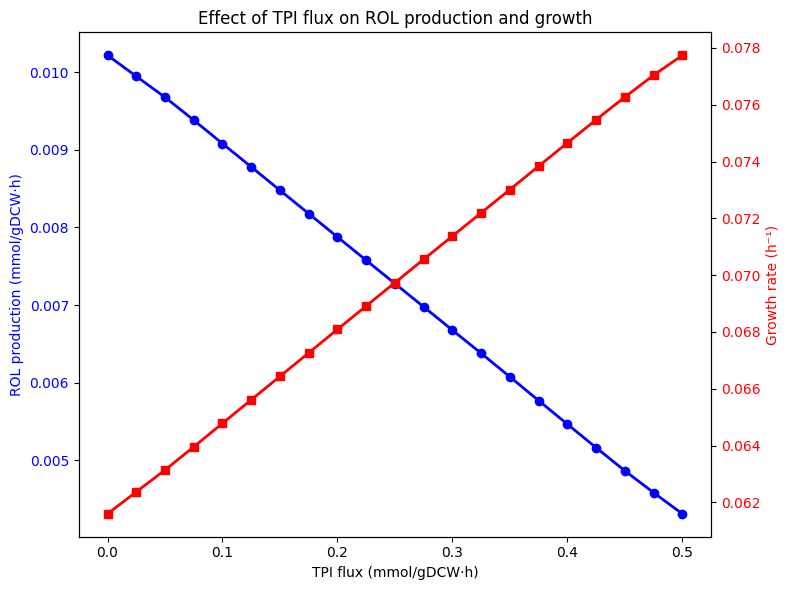

In [36]:
# Extract data from MOMA results
TPI_fluxes = []
ROL_production = []
Biomass = []

for fluxes in MomaResults:
    TPI_fluxes.append(fluxes["TPI"])
    ROL_production.append(fluxes["Ex_rol"])
    Biomass.append(fluxes["Ex_biomass"])


# Create figure
fig, ax1 = plt.subplots(figsize=(8, 6))

# --- ROL production ---
ax1.plot(
    TPI_fluxes,
    ROL_production,
    marker='o',
    linewidth=2,
    color='blue'
)

ax1.set_xlabel("TPI flux (mmol/gDCW·h)")
ax1.set_ylabel("ROL production (mmol/gDCW·h)", color='blue')
ax1.tick_params(axis='y', labelcolor='blue')


# --- Biomass ---
ax2 = ax1.twinx()

ax2.plot(
    TPI_fluxes,
    Biomass,
    marker='s',
    linewidth=2,
    color='red'
)

ax2.set_ylabel("Growth rate (h⁻¹)", color='red')
ax2.tick_params(axis='y', labelcolor='red')


plt.title("Effect of TPI flux on ROL production and growth")

plt.tight_layout()

# Save as PDF
plt.savefig(
    "TPI_MOMA_POS5_KD_ROL_Growth.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()
plt.close()